# Imports

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Helper functions

In [2]:
def det(X):
  return np.linalg.det(X)

def inv(X):
  return np.linalg.inv(X)

# Load and format data

In [3]:
full_data = pd.read_csv("./data/vattuniemi.csv")
generated_data = pd.read_csv("./data/generated_data.csv")

# Pick features and labels
X = generated_data[["Area", "Storeys"]].values
concrete = generated_data[["Concrete"]].values
mineral_wool = generated_data[["Mineral_wool"]].values
metal = generated_data[["Metal"]].values
glass = generated_data[["Glass"]].values

X_tr, X_tst, y_tr, y_tst = train_test_split(X, concrete, test_size=0.2, random_state=42)

# Implement Bayesian linear regression

In [25]:
def BLR(X, y, alpha, beta, mu_0):

  N, F = X.shape

  # Posterior mean mu and covariance matrix S
  S_inv = beta * (X.T @ X) + alpha * np.identity(F)
  S = inv(S_inv)
  mu = S @ ((beta * X.T @ y).flatten() + alpha * mu_0)

  # Log-likelihood (Barber 18.1.19)
  d = (beta * X.T @ y).flatten() + alpha * mu_0
  
  #log_lik = 0.5 * (-beta * y.T @ y + d.T @ S @ d + np.log(det(2 * np.pi * S))
  #          + F * np.log(alpha) + N * np.log(beta) - N * np.log(2 * np.pi))
  #log_lik = -0.5 * np.log(det(2 * np.pi * S)) - 0.5 * y.T @ S_inv
  log_lik = 0.5 * (-beta * y.T @ y + d.T @ S @ d)

  return mu, S, log_lik

7322778.809738335


,Parameter,Value
0,alpha,0.1
1,beta,0.1
2,mu01,2.0
3,mu02,-2.0


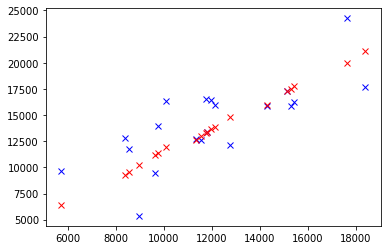

In [26]:
area_mu_0 = np.linspace(-2, 2, 5)
storeys_mu_0 = np.linspace(-2, 2, 5)
alphas = np.linspace(0.1, 20, 100)
betas = np.linspace(0.1, 1, 100)
best_log_lik = -np.inf

for area_mu in area_mu_0:
  for storeys_mu in storeys_mu_0:
    for alpha in alphas:
      for beta in betas:

        mu_0 = np.array([area_mu, storeys_mu])
        post_mu, post_S, log_lik_candidate = BLR(X_tr, y_tr, alpha, beta, mu_0)

        if log_lik_candidate > best_log_lik:
          best_alpha = alpha
          best_beta = beta
          best_log_lik = log_lik_candidate
          best_mu_0 = mu_0

best_mu, best_S, loglik = BLR(X_tr, y_tr, best_alpha, best_beta, best_mu_0)

y_pred = X_tst @ best_mu
mse_test = mean_squared_error(y_tst, y_pred)
print(mse_test)

params = pd.DataFrame({
  'Parameter': ['alpha', 'beta', 'mu01', 'mu02'],
  'Value': [best_alpha, best_beta, best_mu_0[0], best_mu_0[1]]
})
display(params)
fig = plt.figure()
plt.plot(X_tst[:,0], y_tst, 'bx')
plt.plot(X_tst[:,0], y_pred, 'rx')
plt.show()
